In [1]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from IPython.display import Image, display
from typing import Literal
from langgraph.prebuilt import ToolNode

In [2]:
class PriceSplitState(BaseModel):
  net: float
  vat: float = 0
  gross: float = 0

In [3]:
def add_vat(state: PriceSplitState) -> dict:
  return {
    "vat": state.net * 0.22,
    "gross": state.net * 1.22
  }

In [4]:
add_vat_workflow = StateGraph(PriceSplitState)

add_vat_workflow.add_node("add_vat", add_vat)

add_vat_workflow.add_edge(START, "add_vat")
add_vat_workflow.add_edge("add_vat", END)

add_vat_graph = add_vat_workflow.compile()

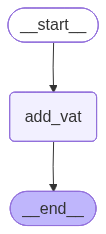

In [5]:
display(Image(add_vat_graph.get_graph().draw_mermaid_png()))

In [6]:
result = add_vat_graph.invoke({ "net": 10 })

In [7]:
result

{'net': 10, 'vat': 2.2, 'gross': 12.2}